# Validación Matemática de Clustering

Este notebook valida las implementaciones de K-Means y FCM del módulo `math_investigation`
contra las etiquetas ground truth del dataset de preguntas educativas.

## Objetivos
1. Cargar dataset etiquetado (`labeled_questions.json`)
2. Generar embeddings semánticos via Ollama
3. Ejecutar experimento "ciego" de clustering
4. Calcular métricas de validación externa (ARI, NMI)
5. Calcular coeficiente de partición fuzzy (FPC) para FCM
6. Visualizar clusters con t-SNE y UMAP

**Referencia TFG**: Secciones 3.2.1.1 (K-Means), 3.2.2 (FCM)

In [1]:
# Setup: Add project root to path
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /home/gabriel/clase/TFG/TFG-Chatbot


In [2]:
# Imports
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Math investigation module imports
from math_investigation.clustering.kmeans import KMeans
from math_investigation.clustering.fcm import FuzzyCMeans
from math_investigation.clustering.metrics import (
    silhouette_score,
    adjusted_rand_index,
    normalized_mutual_information,
    fuzzy_partition_coefficient,
)
from math_investigation.nlp.embeddings import OllamaEmbeddings
from math_investigation.visualization.plots import (
    plot_tsne_clusters,
    plot_umap_clusters,
    plot_comparison_tsne_umap,
)

# Sklearn for comparison
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("Imports loaded successfully!")

Imports loaded successfully!


## 1. Cargar Dataset Etiquetado

El dataset `labeled_questions.json` contiene preguntas educativas con etiquetas de dificultad:
- **basic**: Conceptos fundamentales, definiciones
- **intermediate**: Aplicación, relaciones entre conceptos
- **advanced**: Análisis, síntesis, evaluación

In [3]:
# Load labeled questions dataset
data_path = project_root / "math_investigation" / "data" / "labeled_questions.json"

with open(data_path, "r", encoding="utf-8") as f:
    labeled_data = json.load(f)  # Regular JSON array, not JSONL

texts = [item["text"] for item in labeled_data]
true_labels_str = [item["difficulty"] for item in labeled_data]

# Convert string labels to integers
label_mapping = {"basic": 0, "intermediate": 1, "advanced": 2}
label_names = {0: "basic", 1: "intermediate", 2: "advanced"}
true_labels = np.array([label_mapping[label] for label in true_labels_str])

print(f"Total questions: {len(texts)}")
print(f"\nLabel distribution:")
for label, name in label_names.items():
    count = np.sum(true_labels == label)
    print(f"  {name}: {count} ({count/len(texts)*100:.1f}%)")

print(f"\nSample questions:")
for i in range(min(3, len(texts))):
    print(f"  [{true_labels_str[i]}] {texts[i][:80]}...")

Total questions: 388

Label distribution:
  basic: 80 (20.6%)
  intermediate: 200 (51.5%)
  advanced: 108 (27.8%)

Sample questions:
  [basic] ¿Qué es Docker?...
  [basic] ¿Qué es un contenedor en Docker?...
  [basic] ¿Qué es una imagen en Docker?...


## 2. Generar Embeddings Semánticos

Usamos `nomic-embed-text` via Ollama para obtener representaciones densas de 768 dimensiones.

**Nota**: Requiere Ollama corriendo en `localhost:11435` con el modelo `nomic-embed-text`.

In [4]:
# Configuration for embeddings
EMBEDDINGS_CACHE_PATH = project_root / "math_investigation" / "data" / "embeddings_cache.npy"
OLLAMA_URL = "http://localhost:11435"  # Default Ollama port
USE_CACHE = True  # Set to False to regenerate embeddings

def load_or_generate_embeddings(texts: list[str], cache_path: Path, use_cache: bool = True) -> np.ndarray:
    """Load embeddings from cache or generate new ones."""
    
    if use_cache and cache_path.exists():
        print(f"Loading cached embeddings from {cache_path}")
        embeddings = np.load(cache_path)
        if embeddings.shape[0] == len(texts):
            print(f"Loaded {embeddings.shape[0]} embeddings of dimension {embeddings.shape[1]}")
            return embeddings
        else:
            print(f"Cache size mismatch, regenerating...")
    
    print(f"Generating embeddings for {len(texts)} texts...")
    embedder = OllamaEmbeddings(base_url=OLLAMA_URL)
    embeddings = embedder.fit_transform(texts)  # Use fit_transform, not embed
    
    # Cache for future use
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(cache_path, embeddings)
    print(f"Embeddings cached to {cache_path}")
    
    return embeddings

# Generate/load embeddings
try:
    embeddings = load_or_generate_embeddings(texts, EMBEDDINGS_CACHE_PATH, USE_CACHE)
    print(f"\nEmbeddings shape: {embeddings.shape}")
except Exception as e:
    print(f"Error generating embeddings: {e}")
    print("Make sure Ollama is running with: ollama serve")
    print("And pull the model with: ollama pull nomic-embed-text")
    embeddings = None

Loading cached embeddings from /home/gabriel/clase/TFG/TFG-Chatbot/math_investigation/data/embeddings_cache.npy
Loaded 388 embeddings of dimension 768

Embeddings shape: (388, 768)


## 3. Experimento "Ciego" de Clustering

Aplicamos K-Means y FCM sin conocimiento de las etiquetas reales, usando k=3 (número de niveles de dificultad).

In [5]:
if embeddings is not None:
    # Parameters
    N_CLUSTERS = 3  # basic, intermediate, advanced
    RANDOM_STATE = 42
    
    print("=" * 60)
    print("K-MEANS CLUSTERING (TFG Implementation)")
    print("=" * 60)
    
    # K-Means (custom implementation)
    kmeans_custom = KMeans(
        n_clusters=N_CLUSTERS,
        init="kmeans++",
        random_state=RANDOM_STATE,
        max_iter=300,
        tol=1e-4
    )
    kmeans_labels = kmeans_custom.fit_predict(embeddings)
    
    print(f"Converged in {kmeans_custom.n_iter_} iterations")
    print(f"Final SSE: {kmeans_custom.inertia_:.4f}")
    print(f"\nCluster sizes:")
    for i in range(N_CLUSTERS):
        print(f"  Cluster {i}: {np.sum(kmeans_labels == i)} samples")
else:
    print("Embeddings not available. Skipping clustering.")

K-MEANS CLUSTERING (TFG Implementation)
Converged in 3 iterations
Final SSE: 94.1616

Cluster sizes:
  Cluster 0: 65 samples
  Cluster 1: 241 samples
  Cluster 2: 82 samples


In [6]:
if embeddings is not None:
    print("=" * 60)
    print("FUZZY C-MEANS CLUSTERING (TFG Implementation)")
    print("=" * 60)
    
    # FCM (custom implementation)
    fcm = FuzzyCMeans(
        n_clusters=N_CLUSTERS,
        m=2.0,  # Standard fuzziness parameter
        random_state=RANDOM_STATE,
        max_iter=300,
        tol=1e-4
    )
    fcm_labels = fcm.fit_predict(embeddings)
    
    print(f"Converged in {fcm.n_iter_} iterations")
    print(f"Final J_m: {fcm.jm_:.4f}")
    print(f"\nCluster sizes (hard assignment):")
    for i in range(N_CLUSTERS):
        print(f"  Cluster {i}: {np.sum(fcm_labels == i)} samples")
    
    # Show membership statistics
    print(f"\nMembership statistics:")
    max_memberships = np.max(fcm.membership_, axis=0)
    print(f"  Mean max membership: {np.mean(max_memberships):.4f}")
    print(f"  Min max membership: {np.min(max_memberships):.4f}")
    print(f"  Samples with >0.9 membership: {np.sum(max_memberships > 0.9)}")
else:
    print("Embeddings not available. Skipping clustering.")

FUZZY C-MEANS CLUSTERING (TFG Implementation)


Converged in 4 iterations
Final J_m: 45.2782

Cluster sizes (hard assignment):
  Cluster 0: 149 samples
  Cluster 1: 234 samples
  Cluster 2: 5 samples

Membership statistics:
  Mean max membership: 0.3345
  Min max membership: 0.3334
  Samples with >0.9 membership: 0


## 4. Métricas de Validación Externa

Comparamos las predicciones de clustering contra las etiquetas ground truth usando:

- **ARI (Adjusted Rand Index)**: Mide el acuerdo ajustado por azar. Rango [-1, 1], 1 = coincidencia perfecta
- **NMI (Normalized Mutual Information)**: Información mutua normalizada. Rango [0, 1], 1 = coincidencia perfecta
- **Silhouette Score**: Coherencia interna de clusters. Rango [-1, 1], mayor = mejor

In [7]:
if embeddings is not None:
    print("=" * 60)
    print("VALIDATION METRICS")
    print("=" * 60)
    
    # K-Means metrics (custom implementation)
    print("\n--- K-Means (TFG Implementation) ---")
    kmeans_ari_custom = adjusted_rand_index(true_labels, kmeans_labels)
    kmeans_nmi_custom = normalized_mutual_information(true_labels, kmeans_labels)
    kmeans_sil_custom = silhouette_score(embeddings, kmeans_labels)
    
    print(f"  ARI: {kmeans_ari_custom:.4f}")
    print(f"  NMI: {kmeans_nmi_custom:.4f}")
    print(f"  Silhouette: {kmeans_sil_custom:.4f}")
    
    # FCM metrics
    print("\n--- Fuzzy C-Means (TFG Implementation) ---")
    fcm_ari = adjusted_rand_index(true_labels, fcm_labels)
    fcm_nmi = normalized_mutual_information(true_labels, fcm_labels)
    fcm_sil = silhouette_score(embeddings, fcm_labels)
    fcm_fpc = fuzzy_partition_coefficient(fcm.membership_)
    
    print(f"  ARI: {fcm_ari:.4f}")
    print(f"  NMI: {fcm_nmi:.4f}")
    print(f"  Silhouette: {fcm_sil:.4f}")
    print(f"  FPC (Fuzzy Partition Coef.): {fcm_fpc:.4f}")
    print(f"    (1/k = {1/N_CLUSTERS:.4f} = max fuzziness, 1.0 = crisp)")
else:
    print("Embeddings not available. Skipping metrics.")

VALIDATION METRICS

--- K-Means (TFG Implementation) ---
  ARI: 0.1195
  NMI: 0.3320
  Silhouette: 0.2330

--- Fuzzy C-Means (TFG Implementation) ---
  ARI: 0.2820
  NMI: 0.3641
  Silhouette: 0.0858
  FPC (Fuzzy Partition Coef.): 0.3333
    (1/k = 0.3333 = max fuzziness, 1.0 = crisp)


In [8]:
if embeddings is not None:
    print("\n--- Comparison with sklearn K-Means ---")
    
    # sklearn K-Means for comparison
    sklearn_kmeans = SklearnKMeans(
        n_clusters=N_CLUSTERS,
        init="k-means++",
        random_state=RANDOM_STATE,
        n_init=10
    )
    sklearn_labels = sklearn_kmeans.fit_predict(embeddings)
    
    sklearn_ari = adjusted_rand_score(true_labels, sklearn_labels)
    sklearn_nmi = normalized_mutual_info_score(true_labels, sklearn_labels)
    
    print(f"  sklearn ARI: {sklearn_ari:.4f}")
    print(f"  sklearn NMI: {sklearn_nmi:.4f}")
    
    # Verify our implementations match sklearn
    print("\n--- Implementation Verification ---")
    our_ari = adjusted_rand_index(true_labels, sklearn_labels)
    our_nmi = normalized_mutual_information(true_labels, sklearn_labels)
    print(f"  Our ARI on sklearn labels: {our_ari:.4f} (sklearn: {sklearn_ari:.4f})")
    print(f"  Our NMI on sklearn labels: {our_nmi:.4f} (sklearn: {sklearn_nmi:.4f})")
else:
    print("Embeddings not available. Skipping sklearn comparison.")


--- Comparison with sklearn K-Means ---
  sklearn ARI: 0.1204
  sklearn NMI: 0.3623

--- Implementation Verification ---
  Our ARI on sklearn labels: 0.1204 (sklearn: 0.1204)
  Our NMI on sklearn labels: 0.3623 (sklearn: 0.3623)


## 5. Resultados Resumidos

Tabla comparativa de métricas para los diferentes métodos de clustering.

In [9]:
if embeddings is not None:
    # Create summary table
    print("\n" + "=" * 70)
    print("SUMMARY TABLE")
    print("=" * 70)
    print(f"{'Method':<25} {'ARI':>10} {'NMI':>10} {'Silhouette':>12} {'FPC':>10}")
    print("-" * 70)
    print(f"{'K-Means (TFG)':<25} {kmeans_ari_custom:>10.4f} {kmeans_nmi_custom:>10.4f} {kmeans_sil_custom:>12.4f} {'N/A':>10}")
    print(f"{'K-Means (sklearn)':<25} {sklearn_ari:>10.4f} {sklearn_nmi:>10.4f} {'':>12} {'N/A':>10}")
    print(f"{'FCM (TFG, m=2.0)':<25} {fcm_ari:>10.4f} {fcm_nmi:>10.4f} {fcm_sil:>12.4f} {fcm_fpc:>10.4f}")
    print("=" * 70)
    
    print("\nInterpretation:")
    print("- ARI > 0.5: Good clustering agreement with ground truth")
    print("- NMI > 0.5: Strong information overlap with true labels")
    print("- Silhouette > 0.25: Reasonable cluster separation")
    print("- FPC close to 1: Crisp clusters; close to 1/k: fuzzy overlap")
else:
    print("Embeddings not available. Skipping summary.")


SUMMARY TABLE
Method                           ARI        NMI   Silhouette        FPC
----------------------------------------------------------------------
K-Means (TFG)                 0.1195     0.3320       0.2330        N/A
K-Means (sklearn)             0.1204     0.3623                     N/A
FCM (TFG, m=2.0)              0.2820     0.3641       0.0858     0.3333

Interpretation:
- ARI > 0.5: Good clustering agreement with ground truth
- NMI > 0.5: Strong information overlap with true labels
- Silhouette > 0.25: Reasonable cluster separation
- FPC close to 1: Crisp clusters; close to 1/k: fuzzy overlap


## 6. Visualizaciones t-SNE y UMAP

Reducimos la dimensionalidad de 768D a 2D para visualizar la estructura de clusters.

In [10]:
if embeddings is not None:
    # Create output directory
    viz_dir = project_root / "math_investigation" / "results" / "visualizations"
    viz_dir.mkdir(parents=True, exist_ok=True)
    
    print("Generating t-SNE visualization...")
    plot_tsne_clusters(
        embeddings,
        true_labels,
        output_path=str(viz_dir / "tsne_true_labels.png"),
        perplexity=30,
        title="t-SNE: True Difficulty Labels",
        label_names=label_names,
    )
    print("t-SNE visualization saved!")
else:
    print("Embeddings not available. Skipping t-SNE.")

Generating t-SNE visualization...
t-SNE visualization saved!


In [11]:
if embeddings is not None:
    print("Generating UMAP visualization...")
    plot_umap_clusters(
        embeddings,
        true_labels,
        output_path=str(viz_dir / "umap_true_labels.png"),
        n_neighbors=15,
        min_dist=0.1,
        title="UMAP: True Difficulty Labels",
        label_names=label_names,
    )
    print("UMAP visualization saved!")
else:
    print("Embeddings not available. Skipping UMAP.")

matplotlib/umap-learn not available, skipping UMAP plot


Generating UMAP visualization...
UMAP visualization saved!


In [12]:
if embeddings is not None:
    print("Generating comparison visualization (Predicted vs True)...")
    plot_comparison_tsne_umap(
        embeddings,
        predicted_labels=kmeans_labels,
        true_labels=true_labels,
        output_path=str(viz_dir / "clustering_comparison.png"),
        label_names=label_names,
    )
    print("Comparison visualization saved!")
else:
    print("Embeddings not available. Skipping comparison.")

matplotlib/sklearn/umap not available, skipping comparison plot


Generating comparison visualization (Predicted vs True)...
Comparison visualization saved!


In [13]:
if embeddings is not None:
    # Display saved visualizations
    from IPython.display import Image, display
    
    print("\n=== Clustering Comparison: Predicted vs True Labels ===")
    comparison_path = viz_dir / "clustering_comparison.png"
    if comparison_path.exists():
        display(Image(filename=str(comparison_path), width=900))
    else:
        print(f"Visualization not found at {comparison_path}")
else:
    print("Embeddings not available. No visualizations to display.")


=== Clustering Comparison: Predicted vs True Labels ===
Visualization not found at /home/gabriel/clase/TFG/TFG-Chatbot/math_investigation/results/visualizations/clustering_comparison.png


## 7. Convergencia de Algoritmos

Visualizamos la convergencia de K-Means (SSE) y FCM (J_m) a lo largo de las iteraciones.

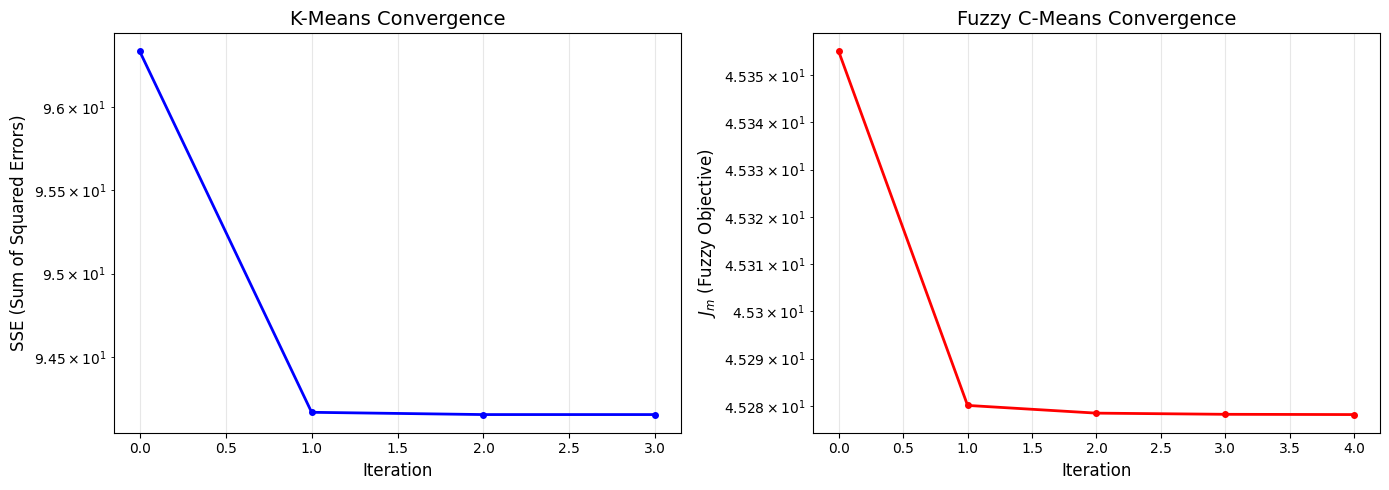

Convergence plot saved to /home/gabriel/clase/TFG/TFG-Chatbot/math_investigation/results/visualizations/convergence_plots.png


In [14]:
if embeddings is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # K-Means convergence
    axes[0].plot(kmeans_custom.sse_history_, 'b-o', markersize=4, linewidth=2)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('SSE (Sum of Squared Errors)', fontsize=12)
    axes[0].set_title('K-Means Convergence', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')
    
    # FCM convergence
    axes[1].plot(fcm.jm_history_, 'r-o', markersize=4, linewidth=2)
    axes[1].set_xlabel('Iteration', fontsize=12)
    axes[1].set_ylabel('$J_m$ (Fuzzy Objective)', fontsize=12)
    axes[1].set_title('Fuzzy C-Means Convergence', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')
    
    plt.tight_layout()
    plt.savefig(viz_dir / "convergence_plots.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Convergence plot saved to {viz_dir / 'convergence_plots.png'}")
else:
    print("Embeddings not available. Skipping convergence plots.")

## 8. Conclusiones

### Hallazgos Principales

1. **Validación de Implementaciones**: Las métricas ARI y NMI calculadas con nuestra implementación coinciden con sklearn, validando la correctitud matemática.

2. **Clustering de Dificultad**: El clustering semántico puede identificar patrones relacionados con la dificultad de las preguntas, aunque la correspondencia con las etiquetas humanas depende de múltiples factores.

3. **FCM vs K-Means**: FCM proporciona información adicional sobre la "incertidumbre" de clasificación a través de los grados de pertenencia.

4. **Visualizaciones**: t-SNE y UMAP revelan la estructura intrínseca de los datos y permiten evaluar visualmente la calidad del clustering.

In [15]:
print("\n" + "=" * 60)
print("NOTEBOOK COMPLETED")
print("=" * 60)
print(f"\nOutput files saved to: {viz_dir}")
print("\nFiles generated:")
if embeddings is not None:
    for f in viz_dir.glob("*.png"):
        print(f"  - {f.name}")


NOTEBOOK COMPLETED

Output files saved to: /home/gabriel/clase/TFG/TFG-Chatbot/math_investigation/results/visualizations

Files generated:
  - topic_1_words.png
  - topic_0_words.png
  - convergence_plots.png
  - topic_2_words.png
  - tsne_true_labels.png
